# Zuko quickstart: normalizing flows in PyTorch

This short tutorial shows how to define, train, evaluate, and sample a normalizing flow using [Zuko](https://zuko.readthedocs.io/).

## Why use Zuko?

- It provides ready-to-use flow architectures such as coupling flows, MAF, neural spline flows, and continuous flows.
- A flow behaves like a PyTorch module and integrates naturally with optimizers and accelerators.
- Calling a flow returns a distribution-like object with familiar methods such as `log_prob()` and `sample()`.
- Conditional density estimation uses the same interface as unconditional density estimation.
- Transformations remain accessible for inspecting latent variables and invertibility.

## 1. Setup

Uncomment the installation command if Zuko is not available in your environment.

In [1]:
# %pip install -q zuko matplotlib

import math
import matplotlib.pyplot as plt
import torch
import zuko

torch.manual_seed(7)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"device={DEVICE} | torch={torch.__version__} | zuko={zuko.__version__}")

device=mps | torch=2.13.0 | zuko=1.6.0


## 2. Create a small dataset

The two-moons distribution is useful because a single Gaussian cannot reproduce its curved, bimodal geometry.

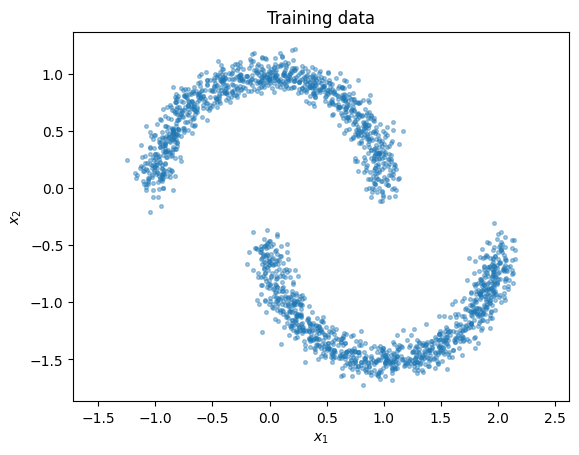

In [2]:
def sample_moons(n=2000, noise=0.08):
    n1 = n // 2
    a = torch.rand(n1, device=DEVICE) * math.pi
    b = torch.rand(n - n1, device=DEVICE) * math.pi
    upper = torch.stack((torch.cos(a), torch.sin(a)), dim=-1)
    lower = torch.stack((1 - torch.cos(b), -torch.sin(b) - 0.5), dim=-1)
    return torch.cat((upper, lower)) + noise * torch.randn(n, 2, device=DEVICE)

raw = sample_moons()
mean, std = raw.mean(0), raw.std(0).clamp_min(1e-6)
data = (raw - mean) / std

plt.scatter(*raw.cpu().T, s=7, alpha=0.4)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Training data")
plt.axis("equal"); plt.show()

## 3. Define a flow

Here we use a neural spline flow (`NSF`). The flow itself is a trainable `torch.nn.Module`. Calling `flow()` creates the current probability distribution.

In [3]:
flow = zuko.flows.NSF(
    features=2,
    transforms=4,
    hidden_features=(64, 64),
    bins=8,
).to(DEVICE)

distribution = flow()
print("log_prob shape:", distribution.log_prob(data[:10]).shape)
print("sample shape:  ", distribution.sample((10,)).shape)
print("parameters:    ", sum(p.numel() for p in flow.parameters()))

log_prob shape: torch.Size([10])
sample shape:   torch.Size([10, 2])
parameters:     29368


## 4. Train by maximum likelihood

Training requires only the negative mean log likelihood:

```python
loss = -flow().log_prob(batch).mean()
```

Zuko handles the inverse transformations and Jacobian determinants internally.

step   1 | NLL 2.769


step 100 | NLL 1.047


step 200 | NLL 1.085


step 300 | NLL 0.977


step 400 | NLL 0.947


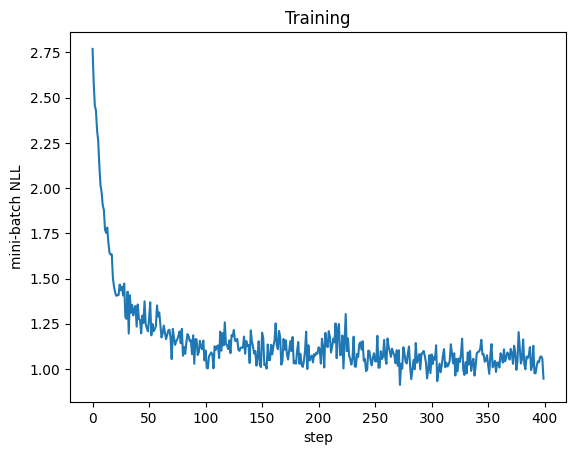

In [4]:
optimizer = torch.optim.Adam(flow.parameters(), lr=2e-3)
losses = []

for step in range(1, 401):
    indices = torch.randint(len(data), (256,), device=DEVICE)
    batch = data[indices]

    loss = -flow().log_prob(batch).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step == 1 or step % 100 == 0:
        print(f"step {step:3d} | NLL {loss.item():.3f}")

plt.plot(losses)
plt.xlabel("step"); plt.ylabel("mini-batch NLL"); plt.title("Training")
plt.show()

## 5. Generate and evaluate

The same learned distribution supports both generation and exact density evaluation.

Full-data NLL: 1.033


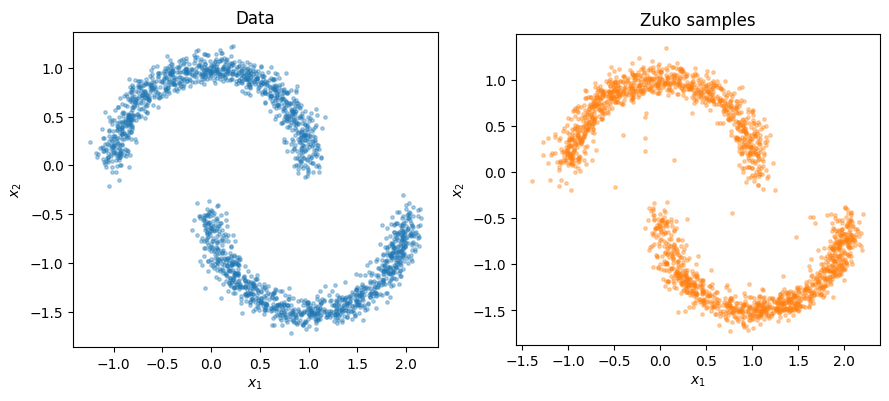

In [5]:
flow.eval()
with torch.no_grad():
    learned = flow()
    generated_std = learned.sample((2000,))
    generated = generated_std * std + mean
    nll = -learned.log_prob(data).mean()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(*raw.cpu().T, s=6, alpha=0.35)
axes[0].set_title("Data")
axes[1].scatter(*generated.cpu().T, s=6, alpha=0.35, color="tab:orange")
axes[1].set_title("Zuko samples")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout()
print(f"Full-data NLL: {nll:.3f}")

## 6. Inspect the latent space

`learned.transform` maps observations to the Gaussian latent space. Its inverse maps latent samples back to data space.

maximum round-trip error: 4.172325134277344e-06


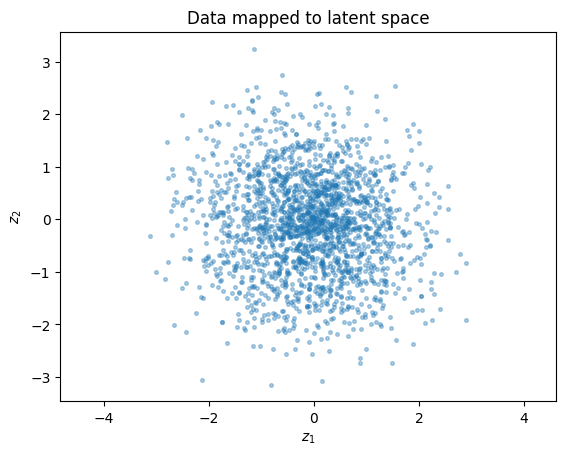

In [6]:
with torch.no_grad():
    latent = learned.transform(data)
    reconstructed = learned.transform.inv(latent)

print("maximum round-trip error:", (data - reconstructed).abs().max().item())

plt.scatter(*latent.cpu().T, s=7, alpha=0.35)
plt.xlabel("$z_1$"); plt.ylabel("$z_2$"); plt.title("Data mapped to latent space")
plt.axis("equal"); plt.show()

## Summary

The essential Zuko workflow is:

```python
flow = zuko.flows.NSF(features=D)
loss = -flow(context).log_prob(data).mean()  # omit context for an unconditional flow
samples = flow(context).sample((number_of_samples,))
```

Zuko is especially convenient when you want to experiment with different flow architectures while keeping the training and sampling code almost unchanged.